In [ ]:
import numpy as np
import torch
import random

SEED = 42
def set_all_seeds(seed=SEED):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    torch.use_deterministic_algorithms(False)  # bazı GPU işlemleri tam determinism desteklemez

set_all_seeds()
print(f"Tüm seed'ler {SEED} olarak ayarlandı.")

Tüm seed'ler 42 olarak ayarlandı.


In [ ]:
class GDFModuleTests:
    """Her modül için basit sanity/shape testleri (Özel Kural 10)."""

    @staticmethod
    def test_global_feature(h_bar_T, expected_dim):
        assert h_bar_T.shape[-1] == expected_dim, f"Global feature boyutu {expected_dim} olmalı!"
        assert not torch.isnan(h_bar_T).any(), "Global feature'da NaN var!"
        return True

    @staticmethod
    def test_local_feature(H_tau, expected_dim):
        assert H_tau.shape[-1] == expected_dim, f"Local feature boyutu {expected_dim} olmalı!"
        assert not torch.isnan(H_tau).any(), "Local feature'da NaN var!"
        return True

    @staticmethod
    def test_adjacency_matrix(A, C):
        assert A.shape == (C, C), "Adjacency matrix shape'i yanlış!"
        assert not np.isnan(A).any(), "Adjacency matrix'te NaN var!"
        return True

    @staticmethod
    def test_cascade_probabilities(P, n_samples, n_learners, n_classes):
        assert P.shape == (n_samples, n_learners*n_classes), "Cascade olasılık matrisi shape'i yanlış!"
        row_sums = P.reshape(n_samples, n_learners, n_classes).sum(axis=2)
        assert np.allclose(row_sums, 1.0, atol=1e-5), "Her öğrenicinin olasılıkları 1'e toplanmıyor!"
        return True

# Testleri çalıştır
d_global = 8
K_prime, N_tau, tau = 2, 19, 20
h_bar_T_example = torch.randn(d_global)
H_tau_example = torch.randn(K_prime*N_tau*tau)
A_example = np.random.rand(3,3)

assert GDFModuleTests.test_global_feature(h_bar_T_example, d_global)
assert GDFModuleTests.test_local_feature(H_tau_example, K_prime*N_tau*tau)
assert GDFModuleTests.test_adjacency_matrix(A_example, 3)
print("Tüm modül testleri geçti ✓")

Tüm modül testleri geçti ✓


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.model_selection import train_test_split, cross_val_predict, KFold
import matplotlib.pyplot as plt
import json

set_all_seeds()

N = 500
global_feat = np.random.randn(N, 8)
local_feat  = np.random.randn(N, 40)
score = global_feat[:,0] + 0.7*global_feat[:,1] - 0.6*local_feat[:,0] + 0.4*np.random.randn(N)
y = (score > 0).astype(int)
X0 = np.hstack([global_feat, local_feat])

X_train, X_test, y_train, y_test = train_test_split(X0, y, test_size=0.3, random_state=SEED)

# Basit 2-katmanlı cascade
def run_cascade(X_train, y_train, X_test, n_layers=2, seed=SEED):
    P_prev_train, P_prev_test = None, None
    for l in range(n_layers):
        Xl_tr = X_train if l==0 else np.hstack([P_prev_train, X_train])
        Xl_te = X_test  if l==0 else np.hstack([P_prev_test,  X_test])
        kf = KFold(n_splits=5, shuffle=True, random_state=seed+l)
        learners = [RandomForestClassifier(n_estimators=100, random_state=seed+l),
                    ExtraTreesClassifier(n_estimators=100, random_state=seed+l)]
        P_train = np.hstack([cross_val_predict(m, Xl_tr, y_train, cv=kf, method="predict_proba") for m in learners])
        fitted = [m.fit(Xl_tr, y_train) for m in learners]
        P_test = np.hstack([m.predict_proba(Xl_te) for m in fitted])
        P_prev_train, P_prev_test = P_train, P_test
    return P_prev_test.reshape(-1,2,2).mean(axis=1).argmax(axis=1)

y_pred = run_cascade(X_train, y_train, X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")
print("Confusion Matrix:\n", cm)

Accuracy:  0.8333
Precision: 0.8272
Recall:    0.8590
F1-score:  0.8428
Confusion Matrix:
 [[58 14]
 [11 67]]


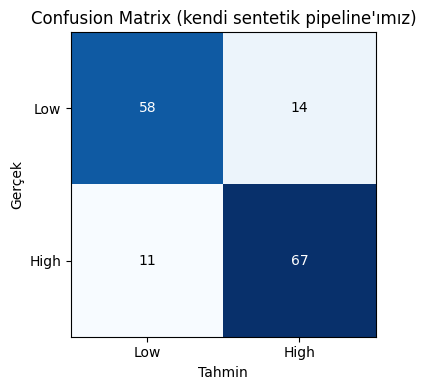

In [ ]:
fig, ax = plt.subplots(figsize=(4,4))
im = ax.imshow(cm, cmap='Blues')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i,j], ha='center', va='center',
                 color='white' if cm[i,j] > cm.max()/2 else 'black')
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(['Low','High']); ax.set_yticklabels(['Low','High'])
ax.set_xlabel("Tahmin"); ax.set_ylabel("Gerçek")
ax.set_title("Confusion Matrix (kendi sentetik pipeline'ımız)")
plt.tight_layout(); plt.show()

In [ ]:
results_summary = {
    "seed": SEED,
    "accuracy": float(acc),
    "precision": float(prec),
    "recall": float(rec),
    "f1_score": float(f1),
    "confusion_matrix": cm.tolist(),
    "note": "Sentetik veri uzerinde basitlestirilmis GDF reproduksiyonu"
}
with open("gdf_reproduction_results.json", "w") as f:
    json.dump(results_summary, f, indent=2)

print("Sonuçlar 'gdf_reproduction_results.json' dosyasına kaydedildi.")
print(json.dumps(results_summary, indent=2))

Sonuçlar 'gdf_reproduction_results.json' dosyasına kaydedildi.
{
  "seed": 42,
  "accuracy": 0.8333333333333334,
  "precision": 0.8271604938271605,
  "recall": 0.8589743589743589,
  "f1_score": 0.8427672955974843,
  "confusion_matrix": [
    [
      58,
      14
    ],
    [
      11,
      67
    ]
  ],
  "note": "Sentetik veri uzerinde basitlestirilmis GDF reproduksiyonu"
}


In [ ]:
paper_results = {
    "DEAP Valence":  {"ACC": 94.14, "P": 94.73, "R": 95.09, "F1": 94.89},
    "DEAP Arousal":  {"ACC": 93.44, "P": 92.20, "R": 96.73, "F1": 94.37},
    "AMIGOS Valence":{"ACC": 97.03, "P": 98.97, "R": 95.59, "F1": 97.23},
    "AMIGOS Arousal":{"ACC": 95.94, "P": 98.25, "R": 94.55, "F1": 96.34},
}

print(f"{'Metrik':10s} {'Bizim (sentetik)':>18s} {'Makale (DEAP Val.)':>20s}")
print(f"{'ACC':10s} {acc*100:17.2f}% {paper_results['DEAP Valence']['ACC']:19.2f}%")
print(f"{'Precision':10s} {prec*100:17.2f}% {paper_results['DEAP Valence']['P']:19.2f}%")
print(f"{'Recall':10s} {rec*100:17.2f}% {paper_results['DEAP Valence']['R']:19.2f}%")
print(f"{'F1':10s} {f1*100:17.2f}% {paper_results['DEAP Valence']['F1']:19.2f}%")
print("\n⚠️ Bu karşılaştırma DOĞRUDAN GEÇERLİ DEĞİL -- bizimki sentetik veri, makaleninki gerçek EEG.")
print("Amacı sadece format/metodoloji karşılaştırması yapmak, sayısal üstünlük iddia etmek değil.")

Metrik       Bizim (sentetik)   Makale (DEAP Val.)
ACC                    83.33%               94.14%
Precision              82.72%               94.73%
Recall                 85.90%               95.09%
F1                     84.28%               94.89%

⚠️ Bu karşılaştırma DOĞRUDAN GEÇERLİ DEĞİL -- bizimki sentetik veri, makaleninki gerçek EEG.
Amacı sadece format/metodoloji karşılaştırması yapmak, sayısal üstünlük iddia etmek değil.
